# RoboVision — Feature Extractors Test
Tests: HOG · SIFT · Color Histogram · Color Moments · Spatial Pyramid

Run each cell with **Shift + Enter**

In [1]:
import pathlib

# Recreate both __init__.py files as truly empty
p1 = pathlib.Path(r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision\robovision\__init__.py")
p2 = pathlib.Path(r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision\robovision\features\__init__.py")

p1.write_text("")
p2.write_text("")

print("Done — both __init__.py recreated cleanly")
print("p1 size:", p1.stat().st_size, "bytes  (should be 0)")
print("p2 size:", p2.stat().st_size, "bytes  (should be 0)")

Done — both __init__.py recreated cleanly
p1 size: 0 bytes  (should be 0)
p2 size: 0 bytes  (should be 0)


In [2]:
import sys, os
PROJECT_ROOT = r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision"
for key in list(sys.modules.keys()):
    if 'robovision' in key: del sys.modules[key]
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

from robovision.io.image_io import read_image
from robovision.features.hog              import extract_hog, extract_hog_visual
from robovision.features.sift             import extract_sift, sift_feature_vector
from robovision.features.color_histogram  import extract_color_histogram, extract_color_histogram_2d
from robovision.features.color_moments    import extract_color_moments, extract_color_moments_hsv
from robovision.features.spatial_pyramid  import extract_spatial_pyramid, extract_spatial_pyramid_gradient
print('imports OK')

imports OK


img_fixed : (128, 128, 3)  gray_fixed: (128, 128)


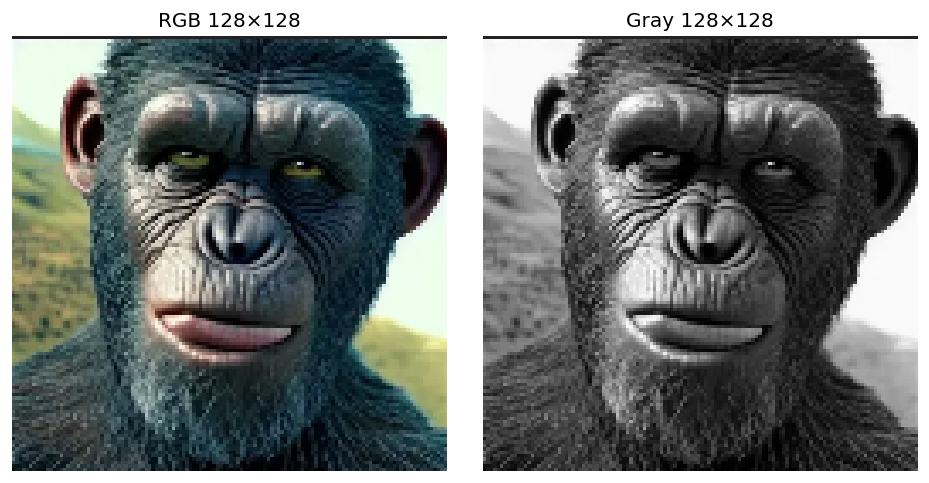

In [3]:
IMG_PATH = r"D:\data ssd\machine vision\happy cesar.png"
img  = read_image(IMG_PATH)
img3 = img[:, :, :3]          # drop alpha if present
from robovision.io.image_io import to_grayscale
gray = to_grayscale(img3)
# Resize to fixed size for consistent descriptor lengths
from robovision.transforms.resize import resize
img_fixed  = resize(img3, (128, 128), method='bilinear')
gray_fixed = resize(gray, (128, 128), method='bilinear')
print(f'img_fixed : {img_fixed.shape}  gray_fixed: {gray_fixed.shape}')
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_fixed);              axes[0].set_title('RGB 128×128'); axes[0].axis('off')
axes[1].imshow(gray_fixed, cmap='gray');axes[1].set_title('Gray 128×128');axes[1].axis('off')
plt.tight_layout(); plt.show()

HOG feature vector: shape=(8100,)  min=0.0000  max=0.7051


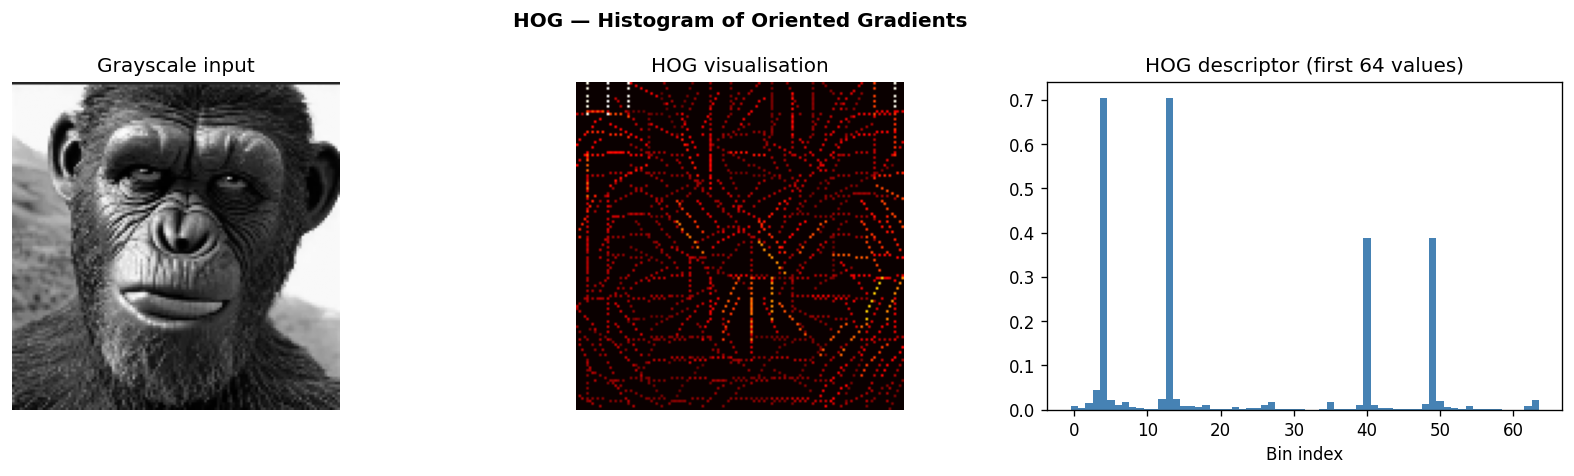

HOG ✓


In [4]:
# ── 1. HOG ───────────────────────────────────────────────────────────────────
hog_feat = extract_hog(gray_fixed, cell_size=8, block_size=2, n_bins=9)
hog_vis  = extract_hog_visual(gray_fixed, cell_size=8)

print(f'HOG feature vector: shape={hog_feat.shape}  min={hog_feat.min():.4f}  max={hog_feat.max():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('HOG — Histogram of Oriented Gradients', fontsize=12, fontweight='bold')
axes[0].imshow(gray_fixed, cmap='gray');  axes[0].set_title('Grayscale input')
axes[1].imshow(hog_vis, cmap='hot');      axes[1].set_title('HOG visualisation')
axes[2].bar(range(len(hog_feat[:64])), hog_feat[:64], width=1.0, color='steelblue')
axes[2].set_title('HOG descriptor (first 64 values)'); axes[2].set_xlabel('Bin index')
for ax in axes[:2]: ax.axis('off')
plt.tight_layout(); plt.show()

assert hog_feat.dtype == np.float32
assert hog_feat.ndim == 1
assert hog_feat.min() >= 0
print('HOG ✓')

Detecting SIFT keypoints (may take a few seconds)...
Keypoints found : 80
Descriptor shape: (80, 128)
Fixed vector    : (128,)


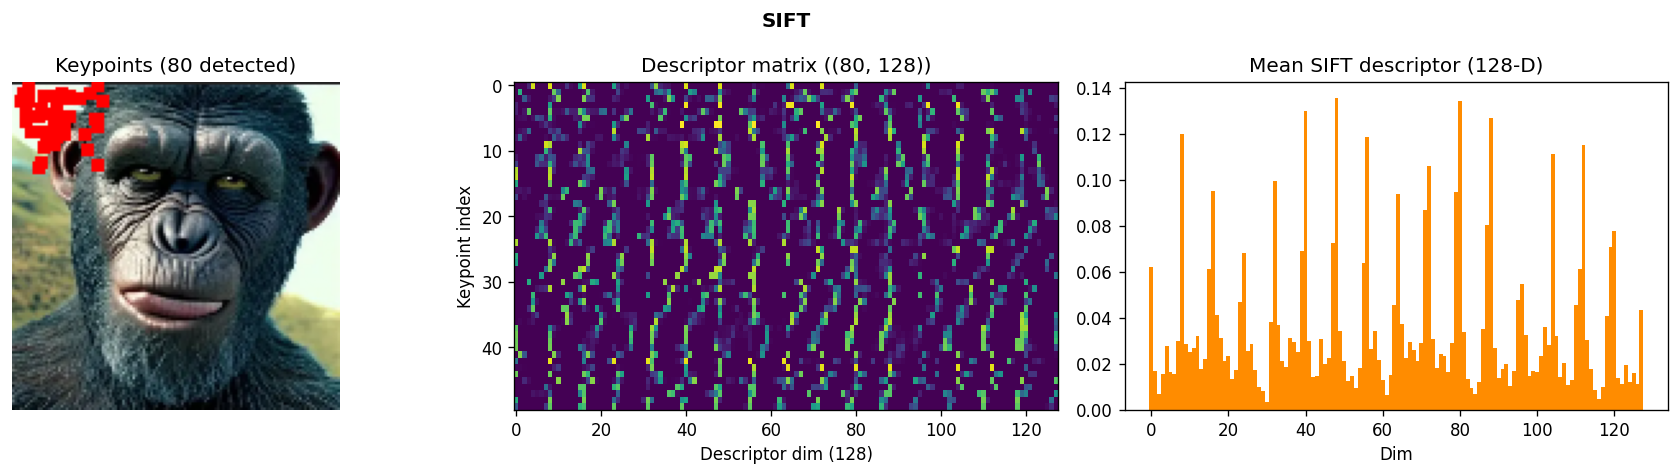

SIFT ✓


In [11]:
# ── 2. SIFT ──────────────────────────────────────────────────────────────────
print('Detecting SIFT keypoints (may take a few seconds)...')
kps, descs = extract_sift(gray_fixed, n_octaves=3, contrast_thresh=0.02, max_keypoints=200)
sift_vec   = sift_feature_vector(gray_fixed, max_keypoints=50)

print(f'Keypoints found : {len(kps)}')
print(f'Descriptor shape: {descs.shape}')
print(f'Fixed vector    : {sift_vec.shape}')

# Draw keypoints on image
vis = img_fixed.copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SIFT', fontsize=12, fontweight='bold')

kp_img = img_fixed.copy()
for kp in kps[:100]:
    r = int(kp.y * 128 / img.shape[0])
    c = int(kp.x * 128 / img.shape[1])
    if 0 <= r < 128 and 0 <= c < 128:
        kp_img[max(0,r-2):r+3, max(0,c-2):c+3] = [1.0, 0.0, 0.0]

axes[0].imshow(kp_img);     axes[0].set_title(f'Keypoints ({len(kps)} detected)')
if len(descs) > 0:
    axes[1].imshow(descs[:min(50,len(descs))], aspect='auto', cmap='viridis')
    axes[1].set_title(f'Descriptor matrix ({descs.shape})')
    axes[1].set_xlabel('Descriptor dim (128)')
    axes[1].set_ylabel('Keypoint index')
axes[2].bar(range(128), sift_vec, width=1.0, color='darkorange')
axes[2].set_title('Mean SIFT descriptor (128-D)'); axes[2].set_xlabel('Dim')
for ax in [axes[0]]: ax.axis('off')
plt.tight_layout(); plt.show()

assert sift_vec.shape == (128,)
assert sift_vec.dtype == np.float32
print('SIFT ✓')

Color histogram (RGB): (96,)
Color histogram (gray): (32,)
2D joint histogram: (16, 16)


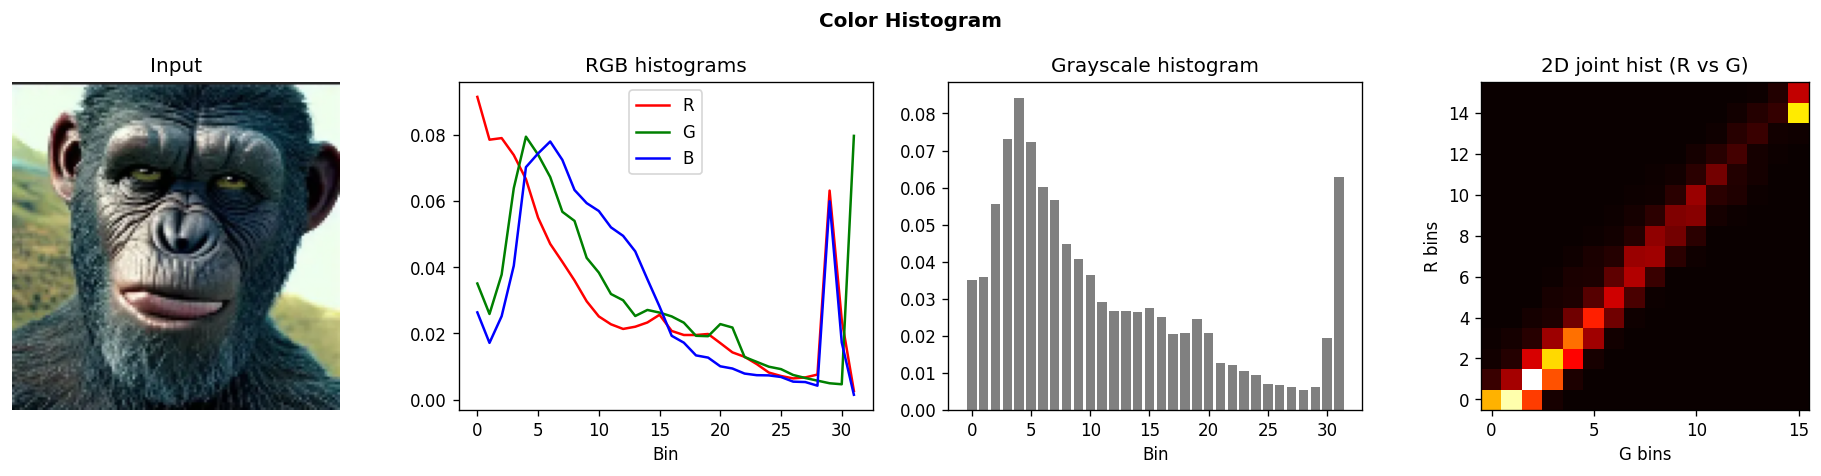

Color Histogram ✓


In [6]:
# ── 3. Color Histogram ───────────────────────────────────────────────────────
ch_feat   = extract_color_histogram(img_fixed, n_bins=32)
ch_gray   = extract_color_histogram(gray_fixed, n_bins=32)
ch_2d     = extract_color_histogram_2d(img_fixed, n_bins=16)

print(f'Color histogram (RGB): {ch_feat.shape}')
print(f'Color histogram (gray): {ch_gray.shape}')
print(f'2D joint histogram: {ch_2d.shape}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Color Histogram', fontsize=12, fontweight='bold')
axes[0].imshow(img_fixed); axes[0].set_title('Input'); axes[0].axis('off')

colors = ['red', 'green', 'blue']
for i, (color, label) in enumerate(zip(colors, ['R', 'G', 'B'])):
    axes[1].plot(ch_feat[i*32:(i+1)*32], color=color, label=label, linewidth=1.5)
axes[1].set_title('RGB histograms'); axes[1].legend(); axes[1].set_xlabel('Bin')

axes[2].bar(range(32), ch_gray, color='gray')
axes[2].set_title('Grayscale histogram'); axes[2].set_xlabel('Bin')

axes[3].imshow(ch_2d, cmap='hot', origin='lower')
axes[3].set_title('2D joint hist (R vs G)'); axes[3].set_xlabel('G bins'); axes[3].set_ylabel('R bins')
plt.tight_layout(); plt.show()

assert ch_feat.shape == (96,)   # 3 channels × 32 bins
assert ch_gray.shape == (32,)
assert abs(ch_feat[:32].sum() - 1.0) < 1e-5   # normalised
print('Color Histogram ✓')

Color Moments (RGB, order=3):
  R: mean=0.3288  std=0.2894  skew=0.2756
  G: mean=0.3763  std=0.2798  skew=0.2698
  B: mean=0.3591  std=0.2421  skew=0.2476

Color Moments (HSV, order=3):
  H: mean=0.4357  std=0.1936  skew=-0.1357
  S: mean=0.3631  std=0.2569  skew=0.2317
  V: mean=0.3986  std=0.2726  skew=0.2619


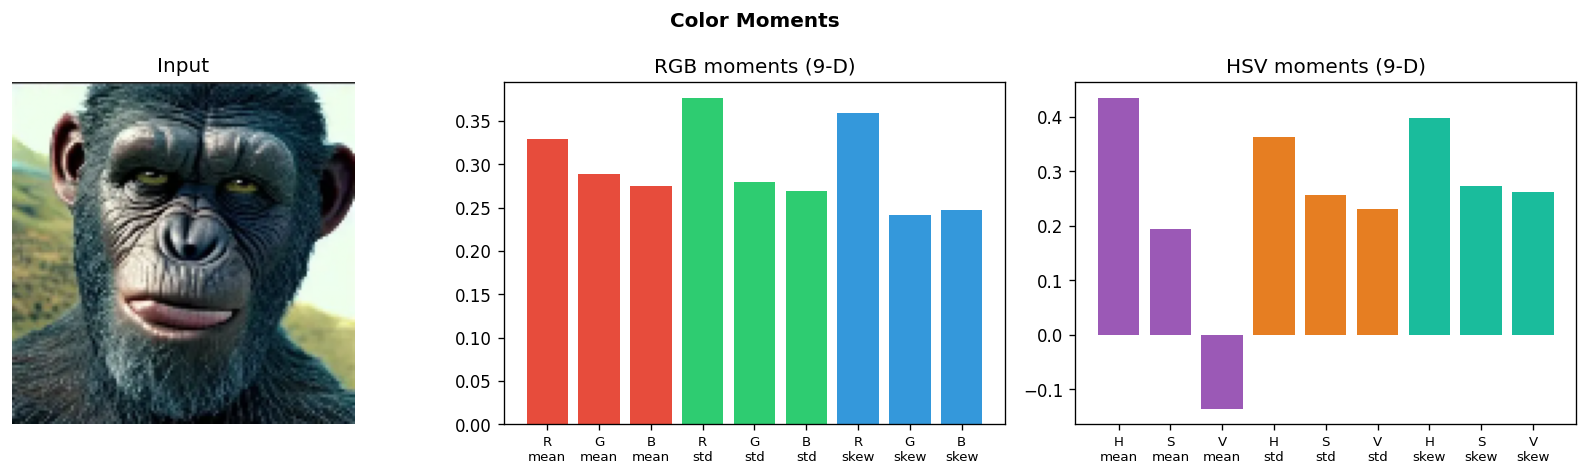

Color Moments ✓


In [7]:
# ── 4. Color Moments ─────────────────────────────────────────────────────────
cm_feat   = extract_color_moments(img_fixed)
cm_hsv    = extract_color_moments_hsv(img_fixed)
cm_order1 = extract_color_moments(img_fixed, order=1)
cm_order2 = extract_color_moments(img_fixed, order=2)

print('Color Moments (RGB, order=3):')
channels = ['R', 'G', 'B']
for i, ch in enumerate(channels):
    mu, sigma, skew = cm_feat[i*3], cm_feat[i*3+1], cm_feat[i*3+2]
    print(f'  {ch}: mean={mu:.4f}  std={sigma:.4f}  skew={skew:.4f}')

print('\nColor Moments (HSV, order=3):')
for i, ch in enumerate(['H', 'S', 'V']):
    mu, sigma, skew = cm_hsv[i*3], cm_hsv[i*3+1], cm_hsv[i*3+2]
    print(f'  {ch}: mean={mu:.4f}  std={sigma:.4f}  skew={skew:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Color Moments', fontsize=12, fontweight='bold')
axes[0].imshow(img_fixed); axes[0].set_title('Input'); axes[0].axis('off')

labels  = [f'{ch}\nmean' for ch in 'RGB'] + [f'{ch}\nstd' for ch in 'RGB'] + [f'{ch}\nskew' for ch in 'RGB']
colors_ = ['#e74c3c']*3 + ['#2ecc71']*3 + ['#3498db']*3
axes[1].bar(range(9), cm_feat, color=colors_)
axes[1].set_xticks(range(9)); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_title('RGB moments (9-D)')

labels_hsv = [f'{ch}\nmean' for ch in 'HSV'] + [f'{ch}\nstd' for ch in 'HSV'] + [f'{ch}\nskew' for ch in 'HSV']
axes[2].bar(range(9), cm_hsv, color=['#9b59b6']*3 + ['#e67e22']*3 + ['#1abc9c']*3)
axes[2].set_xticks(range(9)); axes[2].set_xticklabels(labels_hsv, fontsize=8)
axes[2].set_title('HSV moments (9-D)')
plt.tight_layout(); plt.show()

assert cm_feat.shape   == (9,)
assert cm_hsv.shape    == (9,)
assert cm_order1.shape == (3,)
assert cm_order2.shape == (6,)
assert cm_feat.dtype   == np.float32
print('Color Moments ✓')

SPM color (3 levels, 16 bins, RGB) : (1008,)
SPM gray  (3 levels, 16 bins)      : (336,)
SPM gradient (3 levels, 8 bins)    : (168,)


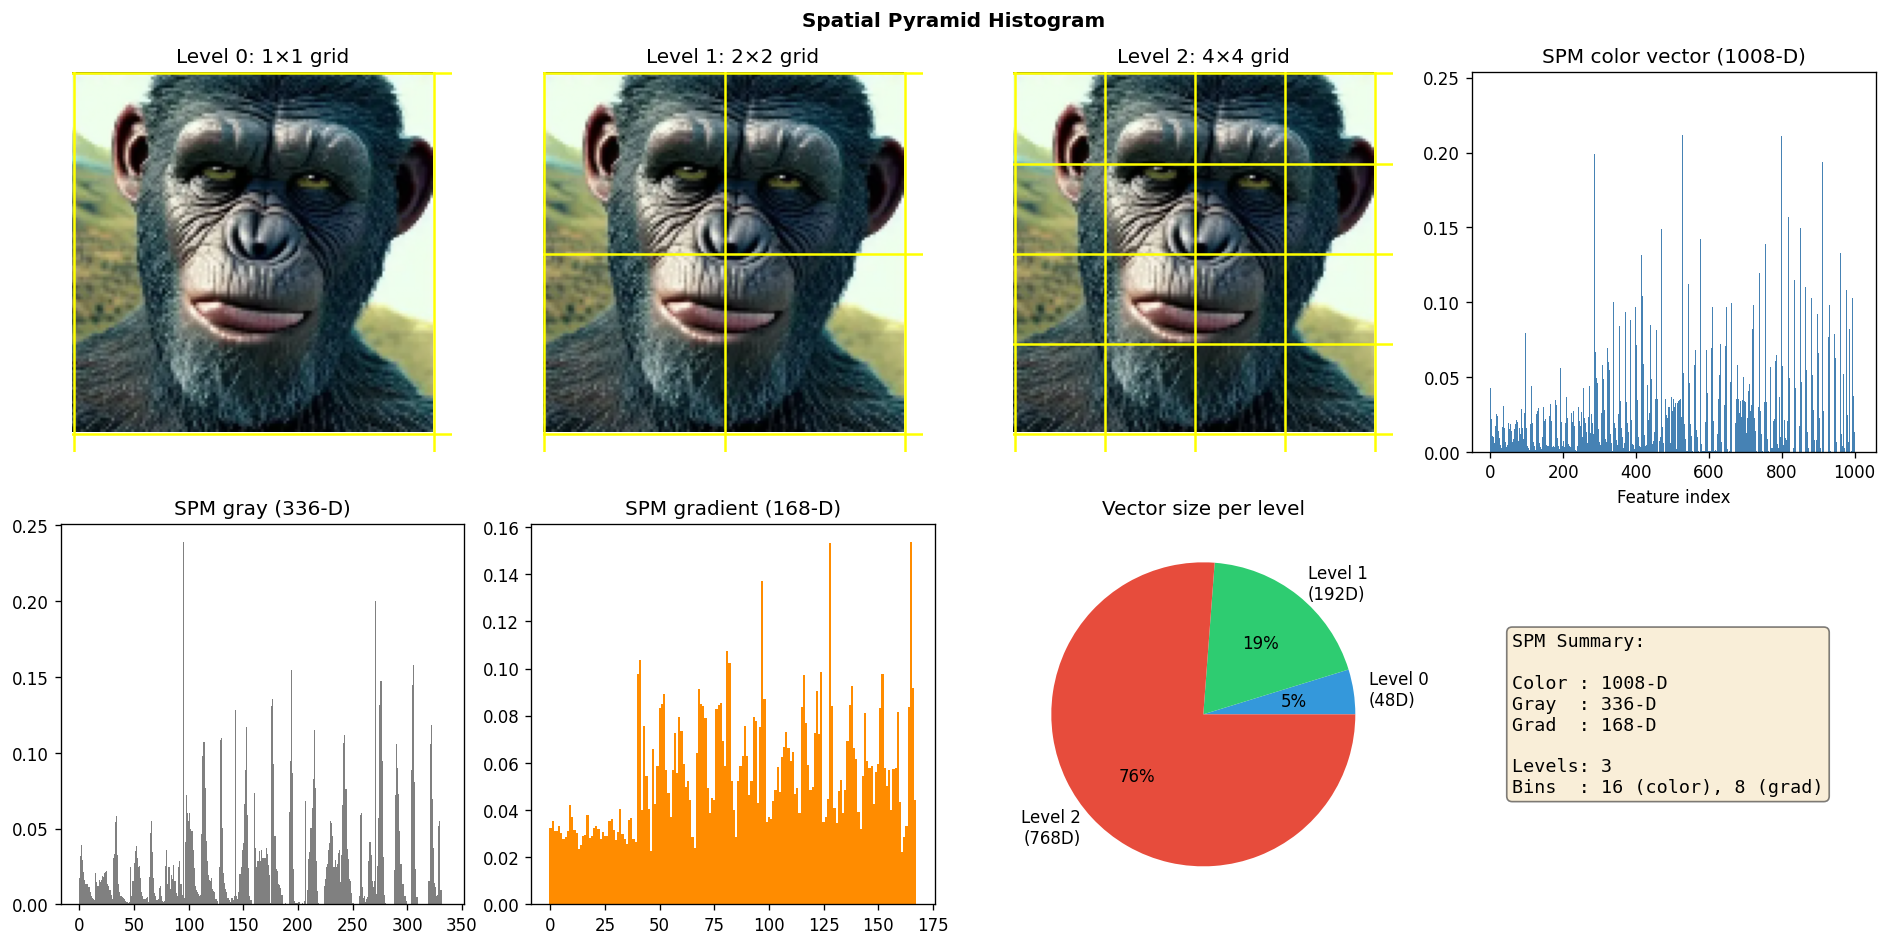

Spatial Pyramid ✓


In [8]:
# ── 5. Spatial Pyramid Histogram ─────────────────────────────────────────────
sp_color = extract_spatial_pyramid(img_fixed, levels=3, n_bins=16)
sp_gray  = extract_spatial_pyramid(gray_fixed, levels=3, n_bins=16, descriptor='gray')
sp_grad  = extract_spatial_pyramid_gradient(img_fixed, levels=3, n_bins=8)

print(f'SPM color (3 levels, 16 bins, RGB) : {sp_color.shape}')
print(f'SPM gray  (3 levels, 16 bins)      : {sp_gray.shape}')
print(f'SPM gradient (3 levels, 8 bins)    : {sp_grad.shape}')

# Visualise the pyramid grid structure
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Spatial Pyramid Histogram', fontsize=12, fontweight='bold')

for level in range(3):
    n_cells = 2 ** level
    ax = axes[0, level]
    ax.imshow(img_fixed)
    for r in range(n_cells + 1):
        ax.axhline(r * 128 / n_cells, color='yellow', linewidth=1.5)
    for c in range(n_cells + 1):
        ax.axvline(c * 128 / n_cells, color='yellow', linewidth=1.5)
    ax.set_title(f'Level {level}: {n_cells}×{n_cells} grid')
    ax.axis('off')

axes[0, 3].bar(range(len(sp_color)), sp_color, width=1.0, color='steelblue')
axes[0, 3].set_title(f'SPM color vector ({sp_color.shape[0]}-D)')
axes[0, 3].set_xlabel('Feature index')

axes[1, 0].bar(range(len(sp_gray)), sp_gray, width=1.0, color='gray')
axes[1, 0].set_title(f'SPM gray ({sp_gray.shape[0]}-D)')

axes[1, 1].bar(range(len(sp_grad)), sp_grad, width=1.0, color='darkorange')
axes[1, 1].set_title(f'SPM gradient ({sp_grad.shape[0]}-D)')

# Show level contributions
level_sizes = [1*3*16, 4*3*16, 16*3*16]  # for RGB
labels_pie  = [f'Level {i}\n({s}D)' for i, s in enumerate(level_sizes)]
axes[1, 2].pie(level_sizes, labels=labels_pie, autopct='%1.0f%%',
               colors=['#3498db','#2ecc71','#e74c3c'])
axes[1, 2].set_title('Vector size per level')

axes[1, 3].axis('off')
info = f'SPM Summary:\n\nColor : {sp_color.shape[0]}-D\nGray  : {sp_gray.shape[0]}-D\nGrad  : {sp_grad.shape[0]}-D\n\nLevels: 3\nBins  : 16 (color), 8 (grad)'
axes[1, 3].text(0.1, 0.5, info, transform=axes[1,3].transAxes,
                fontsize=11, verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(); plt.show()

assert sp_color.dtype == np.float32
assert sp_color.ndim  == 1
assert sp_grad.ndim   == 1
print('Spatial Pyramid ✓')

In [9]:
# ── Combined feature vector summary ──────────────────────────────────────────
features = {
    'HOG (128×128, cell=8)' : extract_hog(gray_fixed),
    'SIFT mean (128-D)'     : sift_feature_vector(gray_fixed),
    'Color Hist (32 bins)'  : extract_color_histogram(img_fixed, n_bins=32),
    'Color Moments RGB'     : extract_color_moments(img_fixed),
    'Color Moments HSV'     : extract_color_moments_hsv(img_fixed),
    'SPM color (3 lvl)'     : extract_spatial_pyramid(img_fixed, levels=3, n_bins=16),
    'SPM gradient (3 lvl)'  : extract_spatial_pyramid_gradient(img_fixed, levels=3, n_bins=8),
}

print('\n Feature Extractor Summary')
print('─' * 45)
total = 0
for name, vec in features.items():
    print(f'  {name:<30} {vec.shape[0]:>6} dims')
    total += vec.shape[0]
print('─' * 45)
print(f'  {"TOTAL (if concatenated)":<30} {total:>6} dims')

# Stack into one mega feature vector
mega_vec = np.concatenate(list(features.values()))
print(f'\n Concatenated vector: {mega_vec.shape}  dtype: {mega_vec.dtype}')
print('All features ✓')


 Feature Extractor Summary
─────────────────────────────────────────────
  HOG (128×128, cell=8)            8100 dims
  SIFT mean (128-D)                 128 dims
  Color Hist (32 bins)               96 dims
  Color Moments RGB                   9 dims
  Color Moments HSV                   9 dims
  SPM color (3 lvl)                1008 dims
  SPM gradient (3 lvl)              168 dims
─────────────────────────────────────────────
  TOTAL (if concatenated)          9518 dims

 Concatenated vector: (9518,)  dtype: float32
All features ✓


In [10]:
# ── Error handling ────────────────────────────────────────────────────────────
tests = [
    (lambda: extract_hog('bad'),                    TypeError,  'hog bad type'),
    (lambda: extract_hog(gray_fixed, cell_size=0),  ValueError, 'hog cell_size=0'),
    (lambda: extract_sift('bad'),                   TypeError,  'sift bad type'),
    (lambda: extract_color_histogram('bad'),        TypeError,  'color_hist bad type'),
    (lambda: extract_color_histogram(img_fixed, n_bins=0), ValueError, 'color_hist n_bins=0'),
    (lambda: extract_color_moments('bad'),          TypeError,  'moments bad type'),
    (lambda: extract_color_moments(img_fixed, order=5), ValueError, 'moments bad order'),
    (lambda: extract_spatial_pyramid('bad'),        TypeError,  'spm bad type'),
    (lambda: extract_spatial_pyramid(img_fixed, levels=0), ValueError, 'spm levels=0'),
]

all_ok = True
for fn, exc, label in tests:
    try:
        fn(); print(f'  FAIL  {label}'); all_ok = False
    except exc:
        print(f'  OK    {label}')
    except Exception as e:
        print(f'  WRONG {label} → {type(e).__name__}: {e}'); all_ok = False

print('\nAll error tests passed ✓' if all_ok else '\nSome FAILED ❌')

  OK    hog bad type
  OK    hog cell_size=0
  OK    sift bad type
  OK    color_hist bad type
  OK    color_hist n_bins=0
  OK    moments bad type
  OK    moments bad order
  OK    spm bad type
  OK    spm levels=0

All error tests passed ✓
